# Análise Exploratória — Finanças de Tutoria

Este notebook carrega os dados do banco SQLite (`data/tutoria.db`), faz a
limpeza/tratamento em pandas e gera os gráficos usados no dashboard e no README.

**Dataset:** sintético, gerado com Faker + regras de negócio (ver `scripts/gerar_dataset.py`).

## 1. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

## 2. Carregar dados do SQLite

In [2]:
conn = sqlite3.connect("../data/tutoria.db")
aulas = pd.read_sql("SELECT * FROM aulas", conn, parse_dates=["data"])
alunos = pd.read_sql("SELECT * FROM alunos", conn, parse_dates=["entrada", "saida"])
conn.close()

print("Shape aulas:", aulas.shape)
aulas.head()

Shape aulas: (582, 7)


,aula_id,data,aluno_id,materia,duracao_horas,valor,status
0,1,2024-05-28,A001,Álgebra Linear,2.0,0.00,Cancelada
1,2,2024-06-04,A001,Álgebra Linear,1.5,102.47,Realizada
2,3,2024-06-18,A001,Álgebra Linear,2.0,136.62,Realizada
3,4,2024-09-21,A002,Cálculo I,1.0,81.76,Realizada
4,5,2024-09-28,A002,Cálculo I,1.0,81.76,Realizada


## 3. Checagem de qualidade dos dados

In [3]:
print(aulas.dtypes)
print()
print("Valores ausentes por coluna:")
print(aulas.isna().sum())

aula_id                   int64
data             datetime64[us]
aluno_id                    str
materia                     str
duracao_horas           float64
valor                   float64
status                      str
dtype: object

Valores ausentes por coluna:
aula_id          0
data             0
aluno_id         0
materia          0
duracao_horas    0
valor            0
status           0
dtype: int64


## 4. Tratamento

Cria colunas derivadas (mês, dia da semana) e isola só as aulas com status
`Realizada`, já que aulas canceladas/faltas não geram receita.

In [4]:
aulas["mes"] = aulas["data"].dt.to_period("M").astype(str)
aulas["dia_semana"] = aulas["data"].dt.day_name()
realizadas = aulas[aulas["status"] == "Realizada"].copy()

realizadas.head()

,aula_id,data,aluno_id,materia,duracao_horas,valor,status,mes,dia_semana
1,2,2024-06-04,A001,Álgebra Linear,1.5,102.47,Realizada,2024-06,Tuesday
2,3,2024-06-18,A001,Álgebra Linear,2.0,136.62,Realizada,2024-06,Tuesday
3,4,2024-09-21,A002,Cálculo I,1.0,81.76,Realizada,2024-09,Saturday
4,5,2024-09-28,A002,Cálculo I,1.0,81.76,Realizada,2024-09,Saturday
5,6,2024-10-05,A002,Cálculo I,1.0,82.23,Realizada,2024-10,Saturday


## 5. Receita mensal + média móvel

A média móvel de 3 meses ajuda a enxergar a tendência por trás da variação
mês a mês (que é bem ruidosa por causa da sazonalidade).

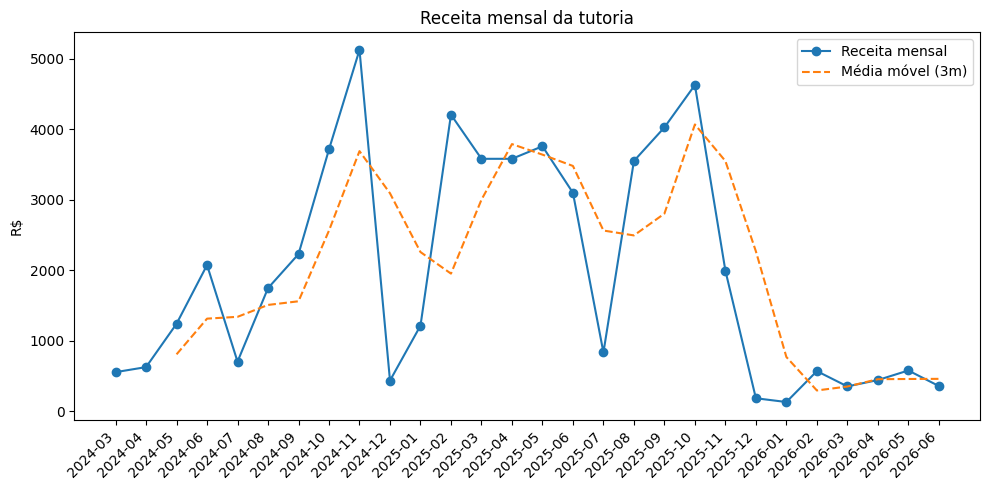

In [5]:
receita_mensal = realizadas.groupby("mes")["valor"].sum().reset_index()
receita_mensal["media_movel_3m"] = receita_mensal["valor"].rolling(3).mean()

plt.figure(figsize=(10, 5))
plt.plot(receita_mensal["mes"], receita_mensal["valor"], marker="o", label="Receita mensal")
plt.plot(receita_mensal["mes"], receita_mensal["media_movel_3m"], linestyle="--", label="Média móvel (3m)")
plt.xticks(rotation=45, ha="right")
plt.title("Receita mensal da tutoria")
plt.ylabel("R$")
plt.legend()
plt.tight_layout()
plt.savefig("../dashboard/receita_mensal.png", dpi=120)
plt.show()

## 6. Receita por matéria

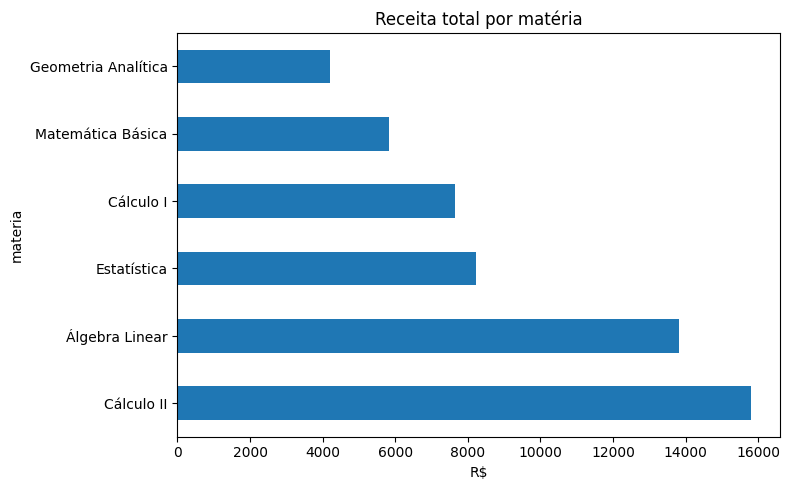

materia
Cálculo II             15808.39
Álgebra Linear         13822.22
Estatística             8236.24
Cálculo I               7648.82
Matemática Básica       5816.28
Geometria Analítica     4192.92
Name: valor, dtype: float64

In [6]:
receita_materia = realizadas.groupby("materia")["valor"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
receita_materia.plot(kind="barh")
plt.title("Receita total por matéria")
plt.xlabel("R$")
plt.tight_layout()
plt.savefig("../dashboard/receita_por_materia.png", dpi=120)
plt.show()

receita_materia

## 7. Taxa de falta por dia da semana

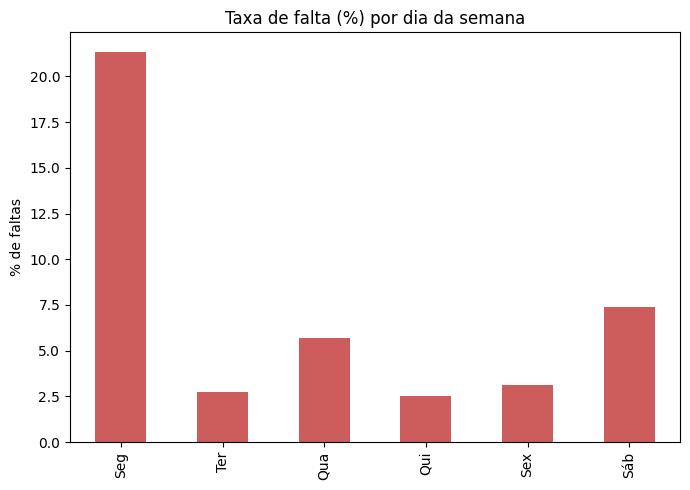

Seg    21.348315
Ter     2.752294
Qua     5.681818
Qui     2.500000
Sex     3.105590
Sáb     7.368421
Name: status, dtype: float64

In [7]:
taxa_falta = (
    aulas.groupby("dia_semana")["status"]
    .apply(lambda s: (s == "Falta").mean() * 100)
    .reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"])
)
taxa_falta.index = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb"]

plt.figure(figsize=(7, 5))
taxa_falta.plot(kind="bar", color="indianred")
plt.title("Taxa de falta (%) por dia da semana")
plt.ylabel("% de faltas")
plt.tight_layout()
plt.savefig("../dashboard/taxa_falta_dia.png", dpi=120)
plt.show()

taxa_falta

## 8. Retenção: tempo de permanência dos alunos

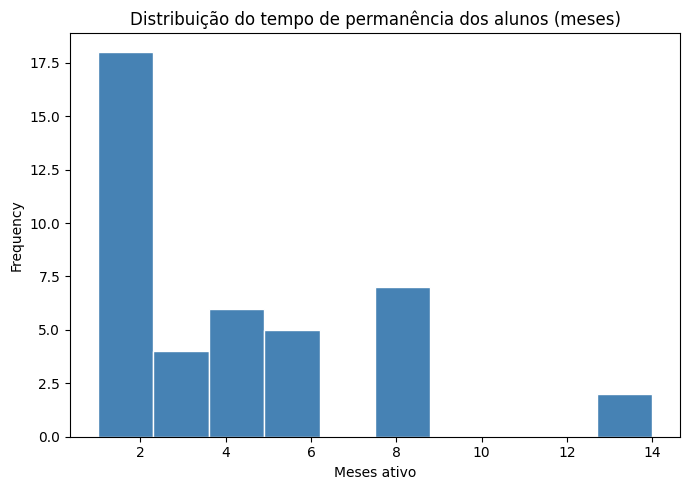

Média de meses ativo: 4.2


In [8]:
alunos["meses_ativo"] = (alunos["saida"] - alunos["entrada"]).dt.days / 30

plt.figure(figsize=(7, 5))
alunos["meses_ativo"].plot(kind="hist", bins=10, color="steelblue", edgecolor="white")
plt.title("Distribuição do tempo de permanência dos alunos (meses)")
plt.xlabel("Meses ativo")
plt.tight_layout()
plt.savefig("../dashboard/retencao_alunos.png", dpi=120)
plt.show()

print("Média de meses ativo:", round(alunos["meses_ativo"].mean(), 1))

## 9. Principais insights

- Segunda-feira tem taxa de falta muito acima da média dos outros dias.
- Duas matérias concentram mais da metade da receita total.
- Receita cresce de forma sustentada, com quedas sazonais recorrentes em
  períodos de férias escolares.